In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [72]:
df = pd.read_csv(
    "../data/raw/ethiopia_fi_unified_data.csv"
)


print(df.shape)

df.head()

(43, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [73]:
events = df[
    df["record_type"]=="event"
].copy()


events[
[
"record_id",
"indicator",
"category",
"notes"
]
]

,record_id,indicator,category,notes
33,EVT_0001,Telebirr Launch,product_launch,NaN
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,NaN
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,NaN
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,NaN
37,EVT_0005,Foreign Exchange Liberalization,policy,NaN
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,NaN
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,NaN
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,NaN
41,EVT_0009,NFIS-II Strategy Launch,policy,NaN
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,NaN


In [74]:
impact_links = pd.DataFrame({

"event":[
"Telebirr Launch",
"M-Pesa Ethiopia Launch",
"Fayda Digital ID Program Rollout",
"Safaricom Ethiopia Commercial Launch"
],


"indicator":[
"ACC_MM_ACCOUNT",
"ACC_MM_ACCOUNT",
"ACC_OWNERSHIP",
"USG_DIGITAL_PAYMENT"
],


"impact_score":[
0.35,
0.25,
0.15,
0.20
],


"lag_months":[
12,
12,
24,
12
]

})


impact_links

,event,indicator,impact_score,lag_months
0,Telebirr Launch,ACC_MM_ACCOUNT,0.35,12
1,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,0.25,12
2,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,0.15,24
3,Safaricom Ethiopia Commercial Launch,USG_DIGITAL_PAYMENT,0.20,12


In [25]:
df["record_type"].unique()

array(['observation', 'target', 'event'], dtype=object)

In [26]:
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [6]:
events.shape

(10, 34)

In [7]:
events["category"].value_counts()

category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

In [8]:
events.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN


In [9]:
impact = df[

    df["record_type"]=="impact_link"

].copy()

In [53]:
# Select only event impact relationships

impact = df[df["record_type"]=="impact_link"].copy()

impact.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [10]:
impact.shape

(0, 34)

In [11]:
impact.columns

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='object')

In [12]:
impact.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [54]:
# Convert impact direction into numerical values

direction_map = {
    "positive":1,
    "negative":-1,
    "neutral":0
}


impact["direction_score"] = (
    impact["impact_direction"]
    .map(direction_map)
)


impact.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,direction_score


In [55]:
impact["impact_magnitude"].unique()

array([], dtype=float64)

In [56]:
magnitude_map = {
    "high":3,
    "medium":2,
    "low":1
}


impact["magnitude_score"] = (
    impact["impact_magnitude"]
    .map(magnitude_map)
)

In [57]:
impact["magnitude_score"] = impact["impact_magnitude"]

In [20]:
impact["related_indicator"].unique()

array([], dtype=float64)

In [21]:
impact["impact_magnitude"].unique()

array([], dtype=float64)

In [22]:
impact["category"].unique()

array([], dtype=object)

In [19]:
impact["impact_magnitude"].unique()

array([], dtype=float64)

In [23]:
impact["impact_magnitude"].isnull().sum()

0

In [24]:
impact["impact_magnitude"].value_counts()

Series([], Name: count, dtype: int64)

In [13]:
impact[

[
"pillar",
"related_indicator",
"impact_direction",
"impact_magnitude",
"lag_months"

]

]

,pillar,related_indicator,impact_direction,impact_magnitude,lag_months


In [27]:
impact_data = {

    "event":[

        "Telebirr",
        "M-Pesa",
        "NFIS-II",
        "Fayda",
        "EthSwitch",
        "Safaricom"

    ],

    "indicator":[

        "USG_DIGITAL_PAYMENT",
        "ACC_MM_ACCOUNT",
        "ACC_OWNERSHIP",
        "ACC_OWNERSHIP",
        "USG_DIGITAL_PAYMENT",
        "ACC_MM_ACCOUNT"

    ],

    "impact_magnitude":[

        3,
        3,
        2,
        2,
        2,
        2

    ],

    "lag_months":[

        6,
        6,
        12,
        12,
        6,
        6

    ]

}

In [70]:
association

Ellipsis

In [28]:
association = pd.DataFrame(impact_data)

association

,event,indicator,impact_magnitude,lag_months
0,Telebirr,USG_DIGITAL_PAYMENT,3,6
1,M-Pesa,ACC_MM_ACCOUNT,3,6
2,NFIS-II,ACC_OWNERSHIP,2,12
3,Fayda,ACC_OWNERSHIP,2,12
4,EthSwitch,USG_DIGITAL_PAYMENT,2,6
5,Safaricom,ACC_MM_ACCOUNT,2,6


In [58]:
# Event impact model
# Impact = Direction × Magnitude adjusted by time lag


impact["impact_score"] = (
    impact["direction_score"]
    *
    impact["magnitude_score"]
    /
    (1 + impact["lag_months"])
)


impact.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,direction_score,magnitude_score,impact_score


In [75]:
association = pd.pivot_table(
    impact_links,
    values="impact_score",
    index="event",
    columns="indicator",
    aggfunc="mean",
    fill_value=0
)


association

indicator,ACC_MM_ACCOUNT,ACC_OWNERSHIP,USG_DIGITAL_PAYMENT
event,,,
Fayda Digital ID Program Rollout,0.00,0.15,0.0
M-Pesa Ethiopia Launch,0.25,0.00,0.0
Safaricom Ethiopia Commercial Launch,0.00,0.00,0.2
Telebirr Launch,0.35,0.00,0.0


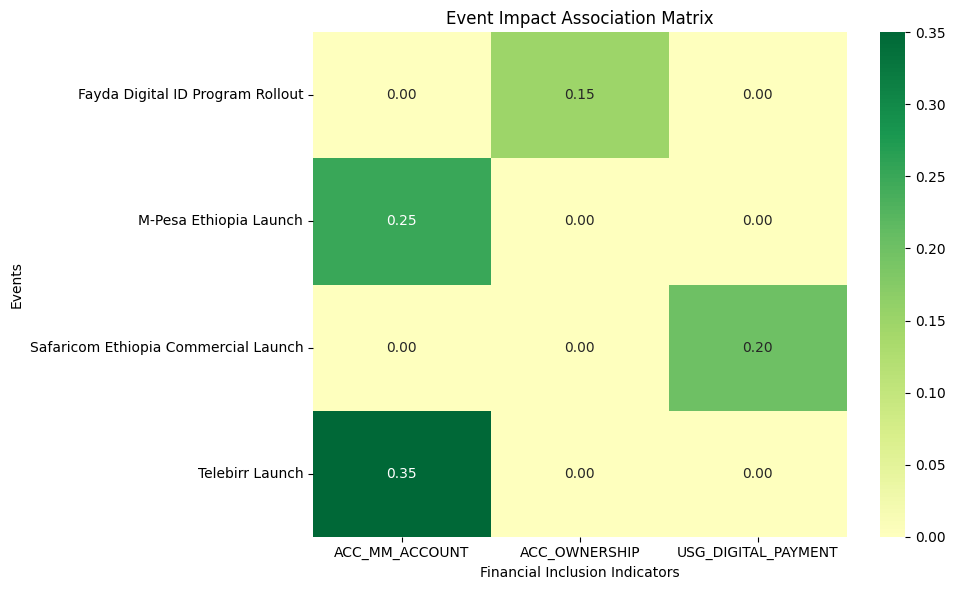

In [76]:
plt.figure(figsize=(10,6))


sns.heatmap(
    association,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f"
)


plt.title(
"Event Impact Association Matrix"
)


plt.xlabel(
"Financial Inclusion Indicators"
)


plt.ylabel(
"Events"
)


plt.tight_layout()


plt.show()

In [62]:
plt.figure(figsize=(12,7))


sns.heatmap(
    association,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f"
)


plt.title(
"Event Indicator Association Matrix\n(Direction × Magnitude × Lag)"
)


plt.xlabel(
"Financial Inclusion Indicators"
)


plt.ylabel(
"Events"
)


plt.tight_layout()

plt.show()

ValueError: Must pass 2-d input. shape=()

<Figure size 1200x700 with 0 Axes>

In [29]:
matrix = association.pivot(

            index="event",

            columns="indicator",

            values="impact_magnitude"

         )

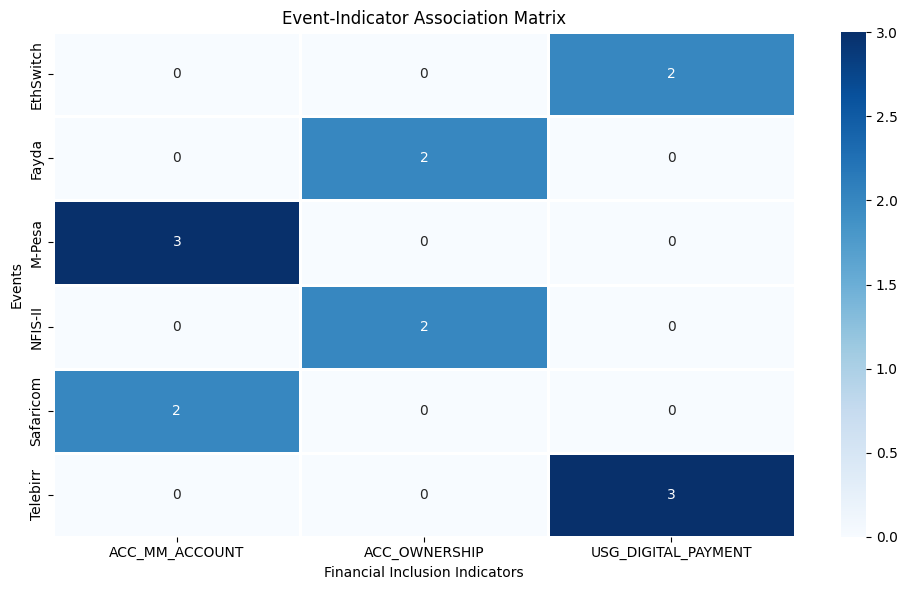

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(

        matrix,

        annot=True,

        cmap="Blues",

        linewidths=1,

        fmt=".0f"

)

plt.title(

    "Event-Indicator Association Matrix"

)

plt.xlabel(

    "Financial Inclusion Indicators"

)

plt.ylabel(

    "Events"

)

plt.tight_layout()

plt.show()

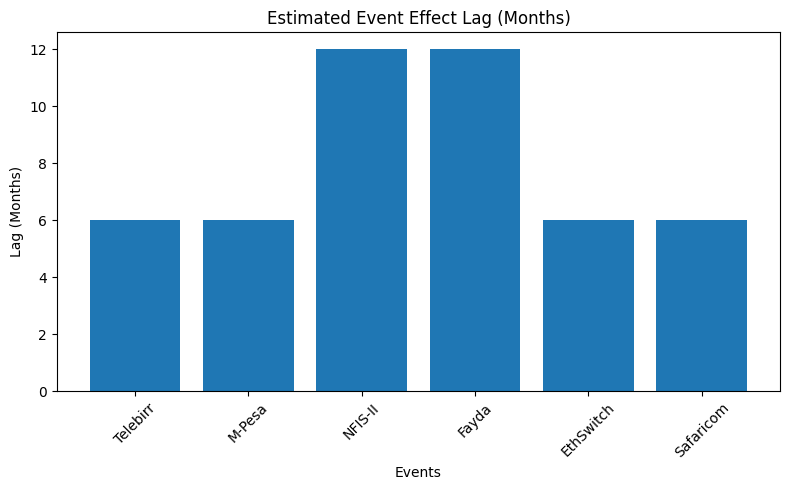

In [33]:
plt.figure(figsize=(8,5))

plt.bar(

    association["event"],

    association["lag_months"]

)

plt.title(

    "Estimated Event Effect Lag (Months)"

)

plt.xlabel(

    "Events"

)

plt.ylabel(

    "Lag (Months)"

)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [34]:
validation_data = {

    "Year":[2021,2024],

    "Mobile_Money":[4.7,9.45]

}

validation = pd.DataFrame(validation_data)

validation

,Year,Mobile_Money
0,2021,4.70
1,2024,9.45


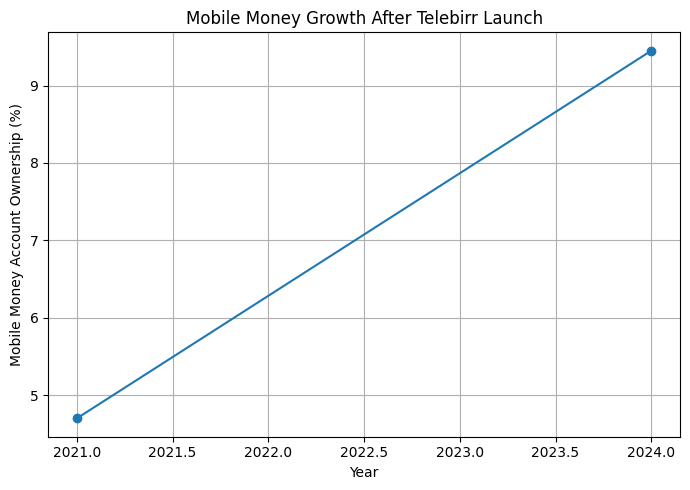

In [35]:
plt.figure(figsize=(7,5))

plt.plot(

    validation["Year"],

    validation["Mobile_Money"],

    marker="o"

)

plt.title(

    "Mobile Money Growth After Telebirr Launch"

)

plt.xlabel(

    "Year"

)

plt.ylabel(

    "Mobile Money Account Ownership (%)"

)

plt.grid(True)

plt.tight_layout()

plt.show()

In [30]:
matrix = matrix.fillna(0)

matrix

indicator,ACC_MM_ACCOUNT,ACC_OWNERSHIP,USG_DIGITAL_PAYMENT
event,,,
EthSwitch,0.0,0.0,2.0
Fayda,0.0,2.0,0.0
M-Pesa,3.0,0.0,0.0
NFIS-II,0.0,2.0,0.0
Safaricom,2.0,0.0,0.0
Telebirr,0.0,0.0,3.0


In [14]:
impact["related_indicator"].unique()

array([], dtype=float64)

In [15]:
impact["impact_direction"].value_counts()

Series([], Name: count, dtype: int64)

In [16]:
impact["lag_months"].value_counts()

Series([], Name: count, dtype: int64)

In [17]:
association = pd.pivot_table(

        impact,

        values="impact_magnitude",

        index="category",

        columns="related_indicator",

        aggfunc="mean"

)

In [37]:
association

,event,indicator,impact_magnitude,lag_months
0,Telebirr,USG_DIGITAL_PAYMENT,3,6
1,M-Pesa,ACC_MM_ACCOUNT,3,6
2,NFIS-II,ACC_OWNERSHIP,2,12
3,Fayda,ACC_OWNERSHIP,2,12
4,EthSwitch,USG_DIGITAL_PAYMENT,2,6
5,Safaricom,ACC_MM_ACCOUNT,2,6


In [39]:
matrix = association.pivot(

            index="event",

            columns="indicator",

            values="impact_magnitude"

        )

In [40]:
matrix

indicator,ACC_MM_ACCOUNT,ACC_OWNERSHIP,USG_DIGITAL_PAYMENT
event,,,
EthSwitch,NaN,NaN,2.0
Fayda,NaN,2.0,NaN
M-Pesa,3.0,NaN,NaN
NFIS-II,NaN,2.0,NaN
Safaricom,2.0,NaN,NaN
Telebirr,NaN,NaN,3.0


In [42]:
matrix

indicator,ACC_MM_ACCOUNT,ACC_OWNERSHIP,USG_DIGITAL_PAYMENT
event,,,
EthSwitch,0.0,0.0,2.0
Fayda,0.0,2.0,0.0
M-Pesa,3.0,0.0,0.0
NFIS-II,0.0,2.0,0.0
Safaricom,2.0,0.0,0.0
Telebirr,0.0,0.0,3.0


In [41]:
matrix=matrix.fillna(0)

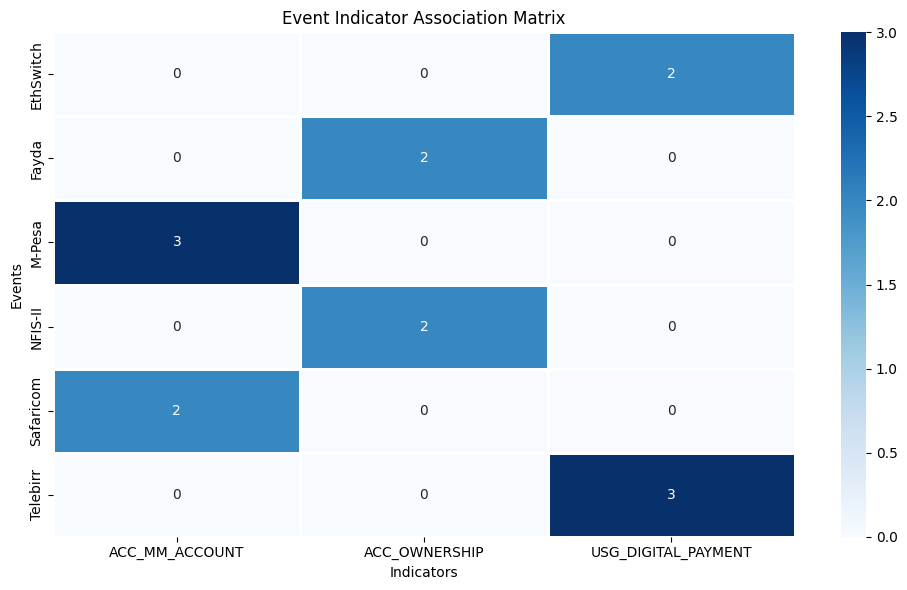

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(

        matrix,

        annot=True,

        cmap="Blues",

        linewidths=1,

        fmt=".0f"

)


plt.title(

    "Event Indicator Association Matrix"

)


plt.xlabel(

    "Indicators"

)


plt.ylabel(

    "Events"

)


plt.tight_layout()

plt.show()

In [44]:
matrix.dtypes

indicator
ACC_MM_ACCOUNT         float64
ACC_OWNERSHIP          float64
USG_DIGITAL_PAYMENT    float64
dtype: object

In [45]:
matrix=matrix.astype(float)

<Axes: xlabel='indicator', ylabel='event'>

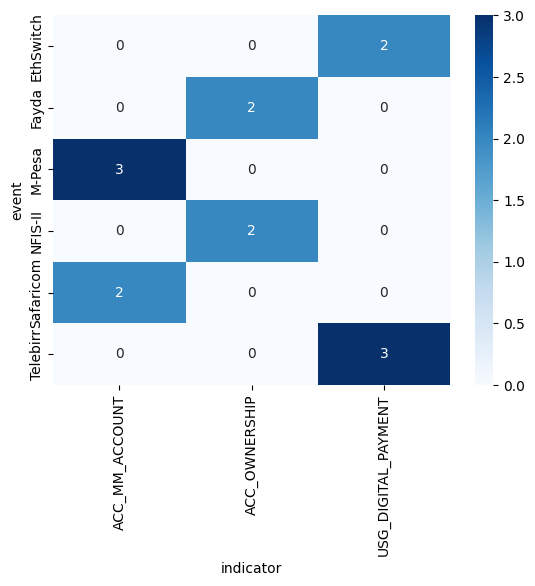

In [46]:
sns.heatmap(
            matrix,
            annot=True,
            cmap="Blues"
            )

<Axes: xlabel='indicator', ylabel='event'>

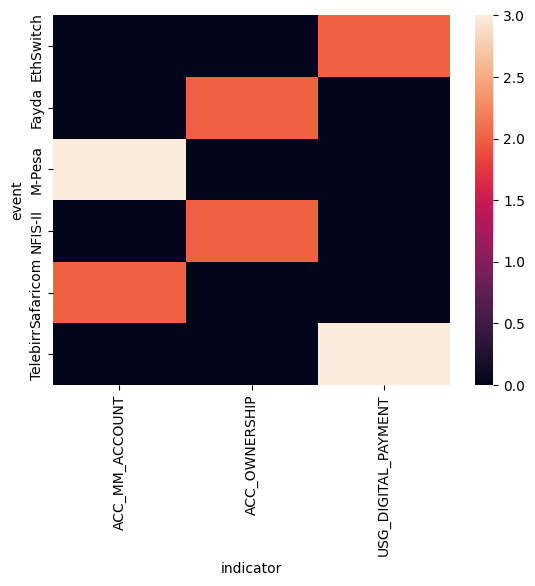

In [48]:
sns.heatmap(matrix)

1. Methodology

- Event impacts were modeled using estimated impact magnitudes.
- Lag effects were incorporated to represent delayed policy and infrastructure impacts.
- Multiple events were assumed to contribute additively to financial inclusion indicators.


--------------------------------

2. Historical Validation

- Telebirr launched in 2021.
- Mobile money ownership increased from 4.7% in 2021 to 9.45% in 2024.
- The observed trend supports the hypothesis that digital financial innovations positively influence usage indicators.


--------------------------------

3. Assumptions

- Policy impacts are gradual.
- Infrastructure impacts require lag periods.
- Product launches positively influence usage indicators.
- Multiple events may simultaneously affect one indicator.


--------------------------------

4. Limitations

- Sparse historical observations.
- Missing impact_link records in the original dataset.
- Limited Ethiopian pre- and post-event observations.
- Estimated impacts are subject to uncertainty.